In [1]:
import os

label_map = {
    "glaucoma": 1, "Glaucoma": 1, "GLAUCOMA": 1,
    "normal": 0, "Normal": 0, "NORMAL": 0,
    "Non Glaucoma": 0
}

def collect_image_paths(root_dir):
    image_paths, labels = [], []
    for subdir, _, files in os.walk(root_dir):
        for fn in files:
            if fn.lower().endswith(('.png','.jpg','.jpeg')):
                class_name = os.path.basename(os.path.normpath(subdir))
                if class_name in label_map:
                    image_paths.append(os.path.join(subdir,fn))
                    labels.append(label_map[class_name])
    return image_paths, labels

In [2]:
import cv2

def extract_roi_and_enhance(image_path, target_size=(224,224)):
    img = cv2.imread(image_path)
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray,(15,15),0)
    _,_,_,maxLoc = cv2.minMaxLoc(blurred)
    x, y = maxLoc

    crop = 300
    x1,y1 = max(0, x-crop), max(0, y-crop)
    x2,y2 = min(img.shape[1], x+crop), min(img.shape[0], y+crop)
    roi = img[y1:y2, x1:x2]

    lab = cv2.cvtColor(roi,cv2.COLOR_BGR2LAB)
    l,a,b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl = clahe.apply(l)
    merged = cv2.merge((cl,a,b))
    enhanced = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)
    resized = cv2.resize(enhanced,target_size)

    return cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

In [3]:
from sklearn.model_selection import train_test_split

paths_acr, labs_acr = collect_image_paths("datasets/ACRIMA")
paths_rim, labs_rim = collect_image_paths("datasets/RIM-ONE")
paths_drs, labs_drs = collect_image_paths("datasets/Drishti-GS1")

all_paths = paths_acr + paths_rim + paths_drs
all_labels = labs_acr + labs_rim + labs_drs

train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.20, stratify=all_labels, random_state=1234
)

In [4]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels, test_size=0.15, stratify=train_labels, random_state=1234
)

In [5]:
from torch.utils.data import Dataset
import torch
from torchvision import transforms
from PIL import Image

class GlaucomaDataset(Dataset):
    def __init__(self, paths, labels):
        self.paths, self.labels = paths, labels
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = extract_roi_and_enhance(self.paths[idx])
        if img is None:
            img = np.zeros((224,224,3),np.uint8)

        img = Image.fromarray(img)
        img = self.transform(img)

        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

In [6]:
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np

# Compute class weights
class_counts = np.bincount(train_labels)
weights = [1.0/class_counts[label] for label in train_labels]

sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_dataset = GlaucomaDataset(train_paths, train_labels)
val_dataset   = GlaucomaDataset(val_paths, val_labels)
test_dataset  = GlaucomaDataset(test_paths, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [49]:
import torch
import torch.nn as nn
import torchvision.models as models

class MultiModelCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # ResNet50
        self.resnet = models.resnet50(weights="DEFAULT")
        resnet_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()

        # DenseNet121
        self.densenet = models.densenet121(weights="DEFAULT")
        densenet_features = self.densenet.classifier.in_features
        self.densenet.classifier = nn.Identity()

        # MobileNetV2
        self.mobilenet = models.mobilenet_v2(weights="DEFAULT")
        mobilenet_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = nn.Identity()

        # Fusion classifier
        total_features = resnet_features + densenet_features + mobilenet_features

        self.classifier = nn.Sequential(
            nn.Linear(total_features, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 1)
        )

    def forward(self, x):
        f1 = self.resnet(x)
        f2 = self.densenet(x)
        f3 = self.mobilenet(x)

        fused = torch.cat([f1, f2, f3], dim=1)
        return self.classifier(fused)

In [8]:
from torch import optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiModelCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\ISHAN/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:20<00:00, 5.06MB/s]


In [9]:
from tqdm import tqdm
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

best_val_auc = 0
EPOCHS = 3
train_losses = []
val_aucs = []

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # Update progress bar postfix
        avg_loss = train_loss / (progress_bar.n + 1)
        progress_bar.set_postfix(avg_loss=avg_loss)

    # Validation
    model.eval()
    val_labels_all, val_scores = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            logits = model(images)
            probs = torch.sigmoid(logits).cpu().numpy()

            val_scores += probs.flatten().tolist()
            val_labels_all += labels.numpy().tolist()

    val_auc = roc_auc_score(val_labels_all, val_scores)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model.state_dict(), "best_model.pth")

    train_losses.append(train_loss/len(train_loader))
    val_aucs.append(val_auc)

    print(f"Epoch {epoch}: Train Loss={train_loss/len(train_loader):.4f}, Val AUC={val_auc:.4f}")

Epoch 1: Train Loss=0.3592, Val AUC=0.9632


Epoch 2: Train Loss=0.1060, Val AUC=0.9692


Epoch 3: Train Loss=0.0451, Val AUC=0.9685


In [10]:
from sklearn.metrics import roc_curve, auc

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_scores, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(device))
        all_scores += torch.sigmoid(logits).cpu().numpy().flatten().tolist()
        all_labels += labels.numpy().flatten().tolist()

fpr, tpr, _ = roc_curve(all_labels, all_scores)
roc_auc = auc(fpr, tpr)

print(f"Test AUC: {roc_auc:.3f}")

Test AUC: 0.989


In [11]:

preds = [1 if s>=0.5 else 0 for s in all_scores]
tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

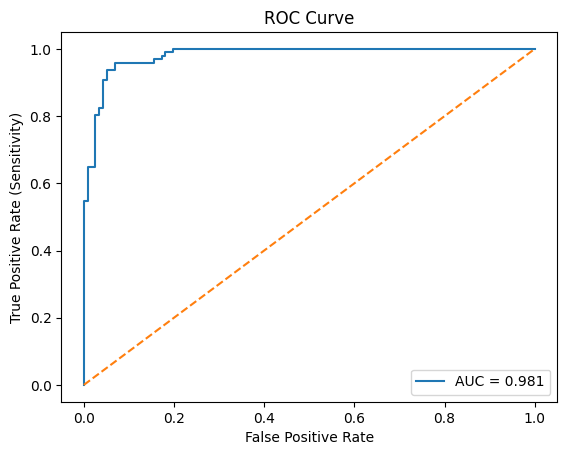

In [31]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve")
plt.legend()
plt.savefig("output/plot1.png", dpi=300, bbox_inches="tight")
plt.show()

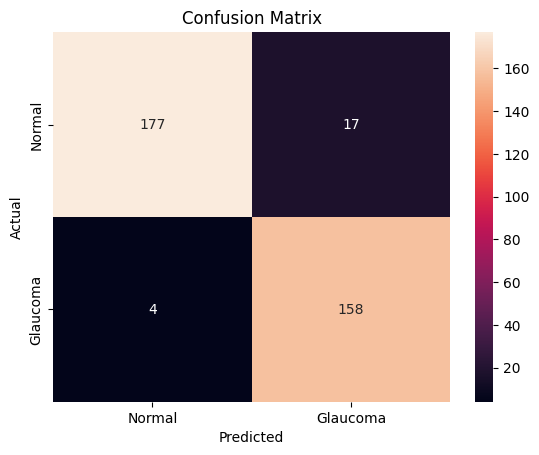

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Normal","Glaucoma"],
            yticklabels=["Normal","Glaucoma"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("output/plot2.png", dpi=300, bbox_inches="tight")
plt.show()

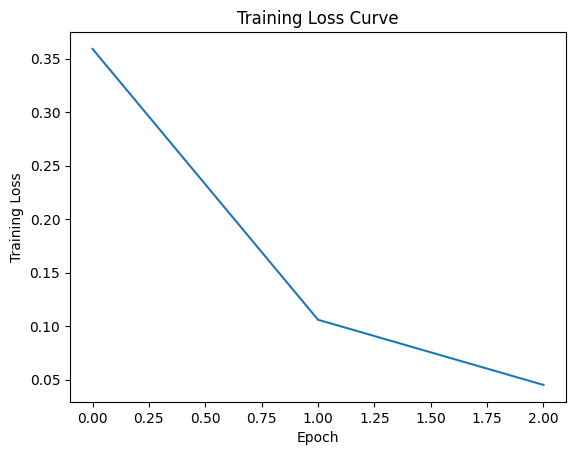

In [33]:
plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.savefig("output/plot3.png", dpi=300, bbox_inches="tight")
plt.show()

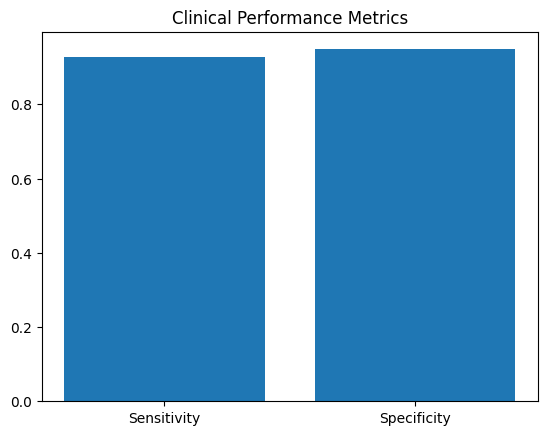

In [34]:
sensitivity = tp/(tp+fn)
specificity = tn/(tn+fp)

plt.figure()
plt.bar(["Sensitivity","Specificity"], [sensitivity, specificity])
plt.title("Clinical Performance Metrics")
plt.savefig("output/plot4.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
import torchvision.models as models

def get_model(name):
    if name == "resnet18":
        model = models.resnet18(weights="DEFAULT")
        model.fc = nn.Linear(model.fc.in_features,1)

    elif name == "densenet121":
        model = models.densenet121(weights="DEFAULT")
        model.classifier = nn.Linear(model.classifier.in_features,1)

    elif name == "mobilenet":
        model = models.mobilenet_v2(weights="DEFAULT")
        model.classifier[1] = nn.Linear(model.classifier[1].in_features,1)
        
    elif name == "multimodel":
        model = MultiModelCNN()
        model.load_state_dict(torch.load("best_model.pth", map_location=device))

    return model.to(device)

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix
import numpy as np
from tqdm import tqdm

results = {}
model_results = {}

def train_and_evaluate(model, train_loader, val_loader, epochs=5):
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.BCEWithLogitsLoss()

    best_auc = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for images, labels in tqdm(train_loader, leave=False):
            images = images.to(device)
            labels = labels.unsqueeze(1).float().to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        model.eval()
        val_scores = []
        val_labels = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)

                logits = model(images)
                probs = torch.sigmoid(logits)

                val_scores.extend(probs.cpu().numpy().flatten())
                val_labels.extend(labels.numpy().flatten())

        if len(set(val_labels)) > 1:
            val_auc = roc_auc_score(val_labels, val_scores)
        else:
            val_auc = 0.5

        if val_auc > best_auc:
            best_auc = val_auc
            best_scores = val_scores.copy()
            best_labels = val_labels.copy()

    preds = (np.array(best_scores) > 0.5).astype(int)
    accuracy = accuracy_score(best_labels, preds)
    cm = confusion_matrix(best_labels, preds)
    
    return best_auc, accuracy, cm, best_labels, best_scores

In [19]:
for model_name in ["resnet18", "densenet121", "mobilenet", "multimodel"]:

    print(f"\nTraining {model_name}...")

    model = get_model(model_name)
    model = model.to(device)

    test_auc, test_acc, cm, val_labels, val_scores = train_and_evaluate(
        model, train_loader, val_loader, epochs=EPOCHS
    )

    tn, fp, fn, tp = cm.ravel()

    results[model_name] = {
        "AUC": test_auc,
        "Accuracy": test_acc,
        "CM": (tn, fp, fn, tp)
    }

    model_results[model_name] = (val_labels, val_scores)
    print(f"{model_name} → AUC: {test_auc:.4f}, Accuracy: {test_acc:.4f}")


Training resnet18...


resnet18 → AUC: 0.9904, Accuracy: 0.9671

Training densenet121...


densenet121 → AUC: 0.9832, Accuracy: 0.9296

Training mobilenet...


mobilenet → AUC: 0.9636, Accuracy: 0.8920

Training multimodel...


multimodel → AUC: 0.9805, Accuracy: 0.9390


In [20]:
import pandas as pd

df_results = pd.DataFrame(results).T
print("\nFinal Model Comparison:")
print(df_results)


Final Model Comparison:
                  AUC  Accuracy                 CM
resnet18     0.990402  0.967136    (111, 5, 2, 95)
densenet121  0.983203  0.929577   (104, 12, 3, 94)
mobilenet    0.963562  0.892019  (104, 12, 11, 86)
multimodel   0.980537  0.938967    (110, 6, 7, 90)


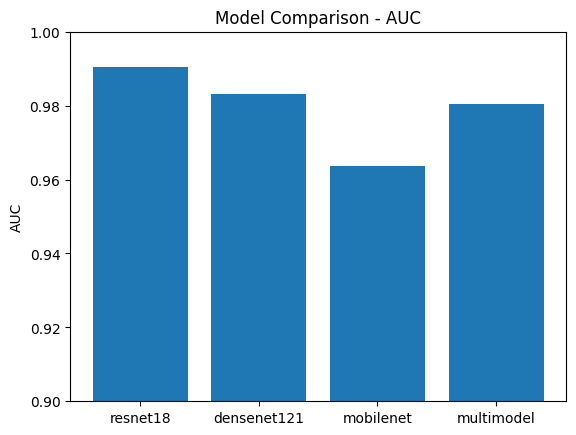

In [35]:
import matplotlib.pyplot as plt

models = list(results.keys())
aucs = [results[m]["AUC"] for m in models]

plt.figure()
plt.bar(models, aucs)
plt.ylabel("AUC")
plt.title("Model Comparison - AUC")
plt.ylim(0.9, 1.0)
plt.savefig("output/plot5.png", dpi=300, bbox_inches="tight")
plt.show()

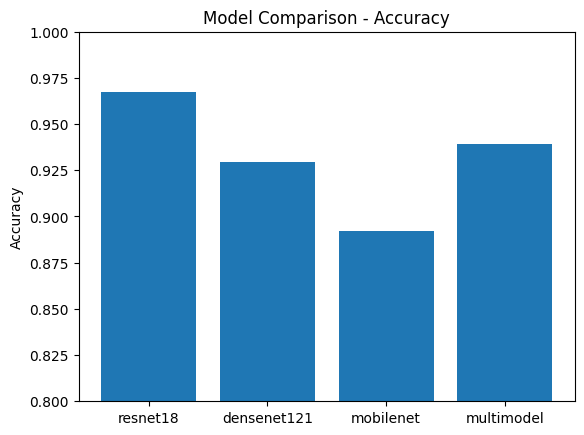

In [22]:
accuracies = [results[m]["Accuracy"] for m in models]

plt.figure()
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Comparison - Accuracy")
plt.ylim(0.8, 1.0)
plt.show()

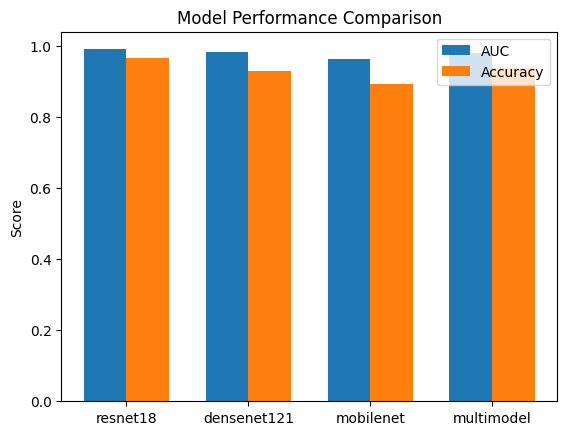

In [36]:
import numpy as np

x = np.arange(len(models))
width = 0.35

plt.figure()
plt.bar(x - width/2, aucs, width, label="AUC")
plt.bar(x + width/2, accuracies, width, label="Accuracy")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.savefig("output/plot6.png", dpi=300, bbox_inches="tight")
plt.show()

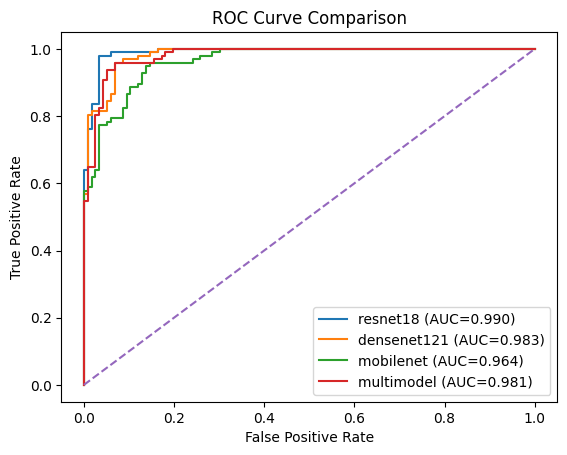

In [37]:
from sklearn.metrics import roc_curve, auc

plt.figure()

for name, (labels, scores) in model_results.items():
    fpr, tpr, _ = roc_curve(labels, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("output/plot7.png", dpi=300, bbox_inches="tight")
plt.show()

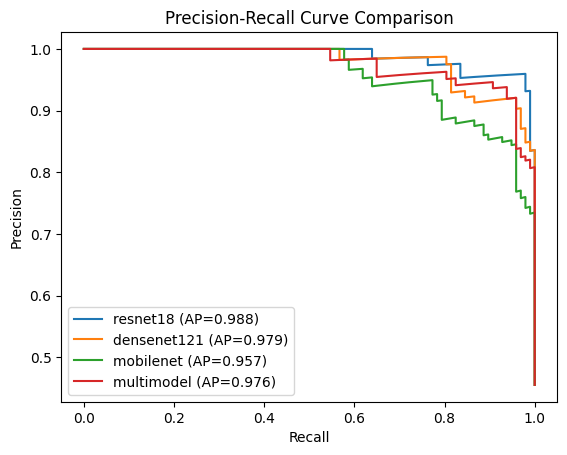

In [38]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure()

for name, (labels, scores) in model_results.items():
    precision, recall, _ = precision_recall_curve(labels, scores)
    ap = average_precision_score(labels, scores)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.savefig("output/plot8.png", dpi=300, bbox_inches="tight")
plt.show()

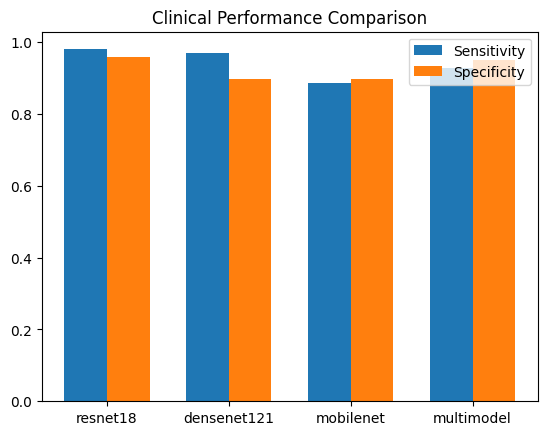

In [39]:
from sklearn.metrics import confusion_matrix

sensitivities = []
specificities = []

for name in models:
    tn, fp, fn, tp = results[name]["CM"]
    sensitivities.append(tp/(tp+fn))
    results[name]["Sensitivity"]=tp/(tp+fn)
    specificities.append(tn/(tn+fp))
    results[name]["Specificity"]=tn/(tp+fn)

x = np.arange(len(models))
width = 0.35

plt.figure()
plt.bar(x - width/2, sensitivities, width, label="Sensitivity")
plt.bar(x + width/2, specificities, width, label="Specificity")

plt.xticks(x, models)
plt.title("Clinical Performance Comparison")
plt.legend()
plt.savefig("output/plot9.png", dpi=300, bbox_inches="tight")
plt.show()

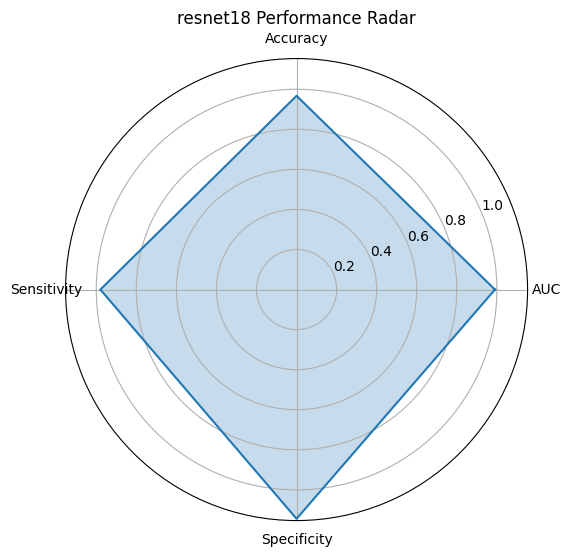

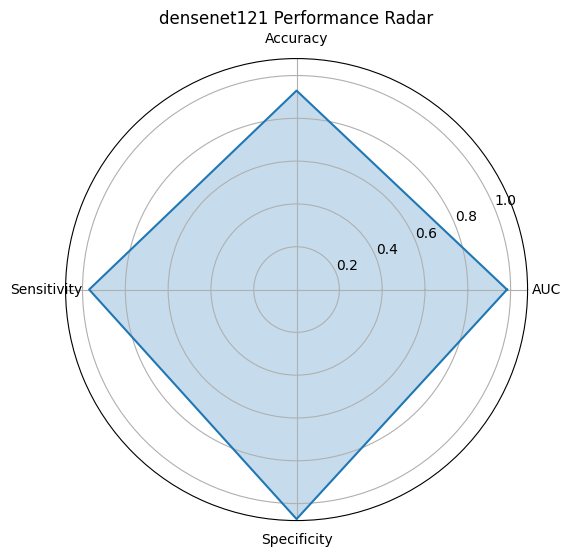

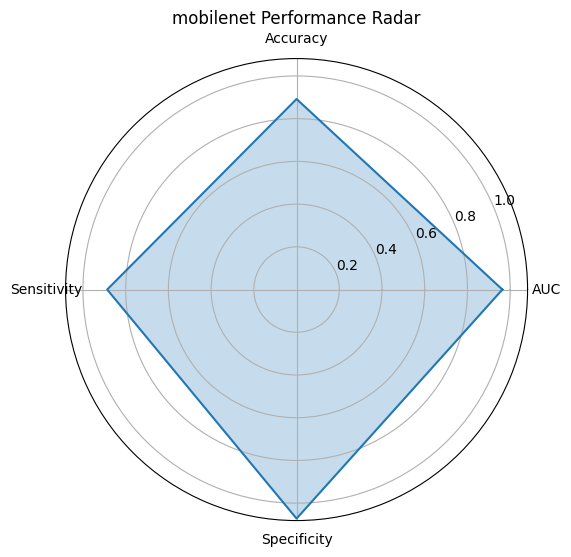

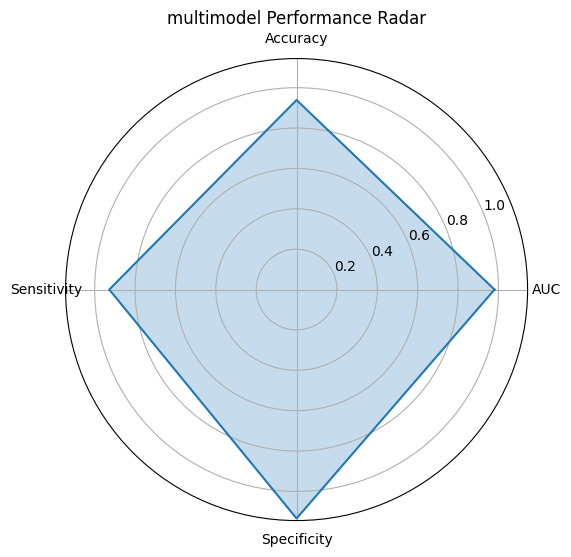

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

metrics = ["AUC", "Accuracy", "Sensitivity", "Specificity"]
N = len(metrics)

angles = np.linspace(0, 2 * pi, N, endpoint=False).tolist()
angles += angles[:1]
i=0

for model in results:

    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)

    values = [results[model][m] for m in metrics]
    values += values[:1]

    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics)

    # ax.set_ylim(0.8, 1.0)
    plt.title(f"{model} Performance Radar")
    
    plt.savefig(f"output/plot{10+i}.png", dpi=300, bbox_inches="tight")
    plt.show()
    i+=1

In [52]:
model = MultiModelCNN()
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()
print("Model loaded")

Model loaded


In [86]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch

idx = random.randint(0, len(test_dataset) - 1)
img_tensor, true_label = test_dataset[idx]
input_tensor = img_tensor.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    logits = model(input_tensor)
    prob = torch.sigmoid(logits).item()
    pred = 1 if prob >= 0.5 else 0

class_names = {0: "Normal", 1: "Abnormal"}

img_np = img_tensor.permute(1, 2, 0).numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img_np = std * img_np + mean
img_np = np.clip(img_np, 0, 1)

img_gray = np.mean(img_np, axis=2)

plt.figure(figsize=(4,4))
plt.imshow(img_np)
plt.title("Original Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(4,4))
plt.imshow(img_gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

plt.figure(figsize=(4,4))
plt.imshow(img_np)
plt.title(
    f"Prediction: {class_names[pred]}\n"
    f"Confidence: {prob:.3f}\n"
    f"True: {class_names[int(true_label.item())]}",
    color="green" if pred == int(true_label.item()) else "red",
    fontweight="bold"
)
plt.axis("off")
plt.show()